# Flux Calibration Sept 19a (Oct 18 flats)

In [1]:
import os
import sys
magePath = '/home/benjamin/Documents/analogs/'
os.sys.path.append(magePath)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.io import fits
from astropy import units as u
from scipy.interpolate import interp1d

from magE.functions import air
from magE.spec.natural_spline import *
from magE.spec.spec_classes import *

In [2]:
# Reduced by BN
# _multispec -> with the -2D flag
# _multi -> without the -2D flag

dataPath = '/home/benjamin/Documents/analogs/calib/mage19a/mage19a18/'

# In this script you must calib

J0950 = MageMultispec.from_fname(dataPath + 'j0950+0042_multi.fits')
J1146 = MageMultispec.from_fname(dataPath + 'j1146+0053_multi.fits')
J1444 = MageMultispec.from_fname(dataPath + 'j1444+0409_multi.fits')
J1448 = MageMultispec.from_fname(dataPath + 'j1448-0110_multi.fits')
J2101 = MageMultispec.from_fname(dataPath + 'j2101-0555_multi.fits')

# Read GD108 and LTT7379 1D spectral data
# GD108 and LTT7379 multispec from CarPy

gd108 = MageMultispec.from_fname(dataPath + 'gd108_multi.fits')
ltt7379 = MageMultispec.from_fname(dataPath + 'ltt7379_multi.fits')
hr4963 = MageMultispec.from_fname(dataPath + 'hr4963_multi.fits')

In [3]:
refPath = '/home/benjamin/Documents/analogs/calib/mage19a/'

# gd108 spectrum from ESO Standard Stars
# keys: 0 -> wavelength (A), 1 -> flux (ergs/cm/cm/s/A * 10**16), 2 -> flux (mJy)

gd108_ref = pd.read_csv(refPath + 'fgd108.dat', header=None, 
                           sep='\s+', engine='python')
simple_gd108 = SimpleSpectrum(lda=gd108_ref[0], 
                                 flux=gd108_ref[1]*1e-16)

# ltt7379 spectrum from ESO Standard Stars
# keys: 0 -> wavelength (A), 1 -> flux (ergs/cm/cm/s/A * 10**16)

ltt7379_ref = pd.read_csv(refPath + 'fltt7379.dat', header=None, sep='\s+', 
                          engine='python')
simple_ltt7379 = SimpleSpectrum(lda=ltt7379_ref[0], flux=ltt7379_ref[1]*1e-16)

# hr4963 spectrum from ESO Standard Stars
# keys: 0 -> wavelength (A), 1 -> flux (ergs/cm/cm/s/A * 10**16)

hr4963_ref = pd.read_csv(refPath + 'fhr4963.dat', header=None, sep='\s+', 
                          engine='python')
simple_hr4963 = SimpleSpectrum(lda=hr4963_ref[0], flux=hr4963_ref[1]*1e-16)

# Reference star spline: LTT 7379

In [4]:
x_ltt = air(simple_ltt7379.lda)
y_ltt = simple_ltt7379.flux

mask_ltt = (x_ltt < 3793) + (x_ltt > 4042) * (x_ltt < 4170) \
         + (x_ltt > 4499) * (x_ltt < 4796) \
         + (x_ltt > 5350) * (x_ltt < 6425) \
         + (x_ltt > 6634) * (x_ltt < 6786) \
         + (x_ltt > 7765) * (x_ltt < 8078) \
         + (x_ltt > 8720) * (x_ltt < 8881) \
         + (x_ltt > 9892)

knots_ltt = np.array([3412, 3651, 4106, 4652, 5799, 6192, 6706,
                     7918, 8793, 9972])

In [5]:
# building spline based model
model_ltt = get_natural_cubic_spline_model(x=simple_ltt7379.lda[mask_ltt],
                                          y=simple_ltt7379.flux[mask_ltt],
                                          minval=np.min(simple_ltt7379.lda[mask_ltt]),
                                          maxval=np.max(simple_ltt7379.lda[mask_ltt]),
                                          knots=knots_ltt)

# getting flux
y_est_custom_model_ltt = model_ltt.predict(simple_ltt7379.lda)

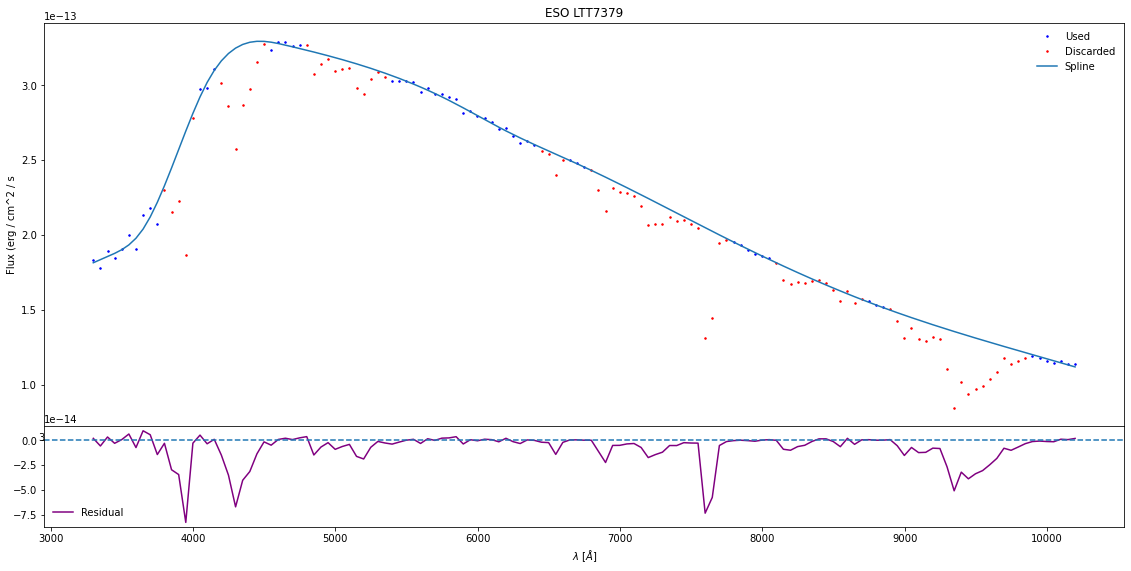

In [6]:
%matplotlib inline

fig = plt.figure(1)
fig.set_size_inches(15, 7)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(simple_ltt7379.lda[mask_ltt], simple_ltt7379.flux[mask_ltt], 
        ls='', marker='.', markersize=3, label='Used', color='blue')
ax.plot(simple_ltt7379.lda[np.logical_not(mask_ltt)], 
        simple_ltt7379.flux[np.logical_not(mask_ltt)], 
        ls='', marker='.', markersize=3, label='Discarded', color='red')
ax.plot(simple_ltt7379.lda, y_est_custom_model_ltt, label='Spline')
ax.legend(frameon=False)
ax.set_ylabel('Flux (erg / cm^2 / s')
ax.set_title('ESO LTT7379')

ax1.plot(x_ltt, y_ltt - y_est_custom_model_ltt, label='Residual', 
         color='purple')
ax1.legend(frameon=False)
ax1.axhline(0, ls='--')
ax1.set_xlabel(r'$\lambda$ [$\AA$]');

In [7]:
reference_lttflux = interp1d(simple_ltt7379.lda,
                              model_ltt.predict(simple_ltt7379.lda),
                              kind='linear', bounds_error=False,
                              fill_value='extrapolate', assume_sorted=True)

## Order 6

In [8]:
xltt6 = ltt7379.wavelength(6)
yltt6 = ltt7379.flux(6)

mask6_ltt = (xltt6 > 9504.07) * (xltt6 < 9515.8) \
          + (xltt6 > 9648.6) * (xltt6 < 9651.8) \
          + (xltt6 > 9893) * (xltt6 < 9897) \
          + (xltt6 > 10105)
knots6_ltt = np.array([9510, 9650, 9895, 10050, 10200,
                       10400, 11000])

In [9]:
model_custom6_ltt = get_natural_cubic_spline_model(x=xltt6[mask6_ltt],
                                                  y=yltt6[mask6_ltt],
                                                  minval=np.min(xltt6),
                                                  maxval=np.max(xltt6),
                                                  knots=knots6_ltt)
y_est_custom6_ltt = model_custom6_ltt.predict(ltt7379.wavelength(6))

In [10]:
obs_flux6_ltt = spectres(simple_ltt7379.lda, ltt7379.wavelength(6), 
                     y_est_custom6_ltt, verbose=False)

factor6_ltt = reference_lttflux(simple_ltt7379.lda)/obs_flux6_ltt

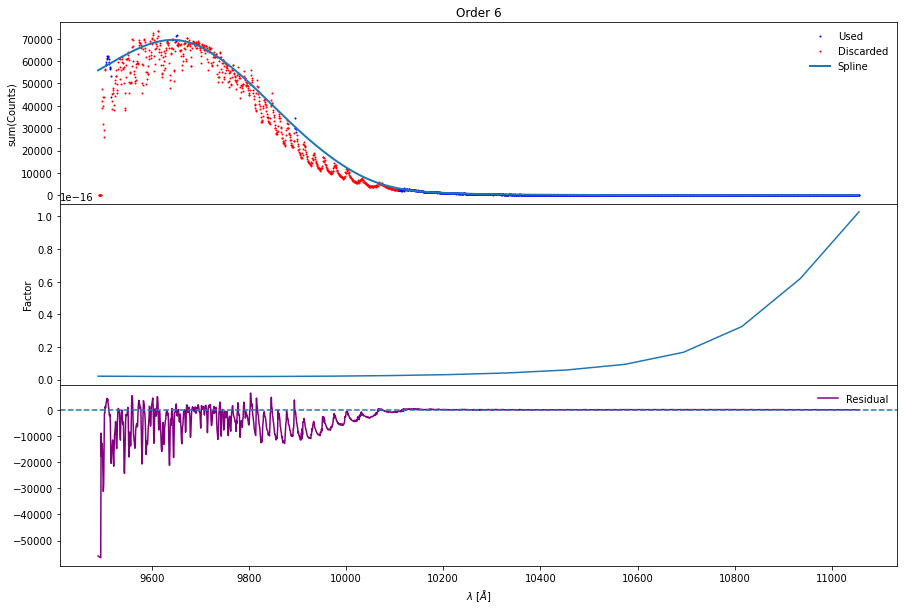

In [11]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(xltt6[mask6_ltt], yltt6[mask6_ltt], ls='', marker='.', markersize=2,
            label='Used', color='blue')
axs[0].plot(xltt6[np.logical_not(mask6_ltt)], yltt6[np.logical_not(mask6_ltt)],
            ls='', marker='.', markersize=2, label='Discarded', color='red')
axs[0].plot(gd108.wavelength(6), y_est_custom6_ltt, lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('sum(Counts)')
axs[0].set_title('Order 6')

axs[1].plot(simple_ltt7379.lda, factor6_ltt)
axs[1].set_ylabel('Factor')

axs[2].plot(ltt7379.wavelength(6), ltt7379.flux(6) - y_est_custom6_ltt,
            label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]');

## Order 7

In [12]:
xltt7 = ltt7379.wavelength(7)
yltt7 = ltt7379.flux(7)

mask7_ltt = (xltt7 > 8170) * (xltt7 < 8174) + (xltt7 > 8409) * (xltt7 < 8412) \
        + (xltt7 > 8557) * (xltt7 < 8565) + (xltt7 > 8599) * (xltt7 < 8607) \
        + (xltt7 > 8849) * (xltt7 < 8854) + (xltt7 > 8919) * (xltt7 < 8926) \
        + (xltt7 > 9049) * (xltt7 < 9057) + (xltt7 > 9199) * (xltt7 < 9203) \
        + (xltt7 > 9462) * (xltt7 < 9466)

knots7_ltt = np.array([8172, 8411, 8560, 8603, 8851, 8923, 9053, 
                      9201, 9464])

In [13]:
model_custom7_ltt = get_natural_cubic_spline_model(x=xltt7[mask7_ltt],
                                                   y=yltt7[mask7_ltt], 
                                                   minval=np.min(xltt7),
                                                   maxval=np.max(xltt7), 
                                                   knots=knots7_ltt)

y_est_custom7_ltt = model_custom7_ltt.predict(ltt7379.wavelength(7))

In [14]:
obs_flux7_ltt = spectres(simple_ltt7379.lda, ltt7379.wavelength(7), 
                     y_est_custom7_ltt, verbose=False)

factor7_ltt = reference_lttflux(simple_ltt7379.lda)/obs_flux7_ltt

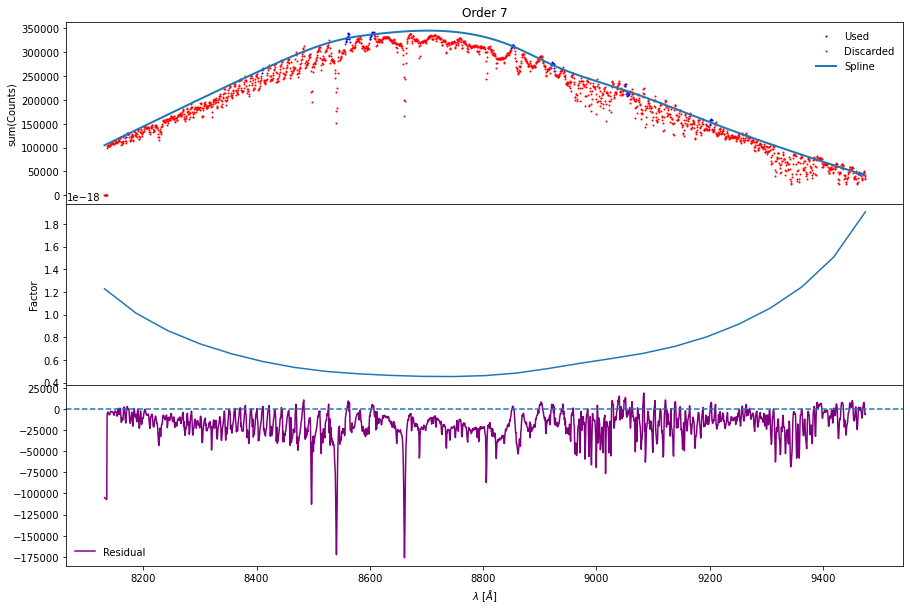

In [15]:
%matplotlib inline

fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(xltt7[mask7_ltt], yltt7[mask7_ltt], ls='', marker='.', markersize=2,
            label='Used', color='blue')
axs[0].plot(xltt7[np.logical_not(mask7_ltt)], yltt7[np.logical_not(mask7_ltt)],
            ls='', marker='.', markersize=2, label='Discarded', color='red')
#ax[0].errorbar(feige110.wavelength(6), feige110.flux(6), feige110.noise(6), ls='', marker='.', markersize=2, label='Observed')
axs[0].plot(ltt7379.wavelength(7), y_est_custom7_ltt, lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('sum(Counts)')
axs[0].set_title('Order 7')

axs[1].plot(simple_ltt7379.lda, factor7_ltt)
axs[1].set_ylabel('Factor')

axs[2].plot(ltt7379.wavelength(7), ltt7379.flux(7) - y_est_custom7_ltt,
            label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]');

## Order 8

In [16]:
yltt8_1 = ltt7379.flux(8)[5:833]
xltt8_1 = ltt7379.wavelength(8)[5:833]

yltt8_int = ltt7379.flux(8)[833:1032]
xltt8_int = ltt7379.wavelength(8)[833:1032]

yltt8_2 = ltt7379.flux(8)[1032:]
xltt8_2 = ltt7379.wavelength(8)[1032:]

mask8_1_ltt = (xltt8_1 > 7123) * (xltt8_1 < 7144) \
           + (xltt8_1 > 7219) * (xltt8_1 < 7221) \
           + (xltt8_1 > 7378) * (xltt8_1 < 7380) \
           + (xltt8_1 > 7450) * (xltt8_1 < 7457) \
           + (xltt8_1 > 7499) * (xltt8_1 < 7504) \
           + (xltt8_1 > 7559) * (xltt8_1 < 7562)

mask8_2_ltt = (xltt8_2 > 7751) * (xltt8_2 < 7756) + (xltt8_2 > 7835) * (xltt8_2 < 7839) \
           + (xltt8_2 > 7966.5) * (xltt8_2 < 7969.3) \
           + (xltt8_2 > 8079) * (xltt8_2 < 8080) \
           + (xltt8_2 > 8245)

knots8_1_ltt = np.array([7130, 7220, 7379, 7454, 7502, 7560])
knots8_2_ltt = np.array([7753, 7837, 7968, 8079.5, 8260, 8284])

In [17]:
model_custom8_1_ltt = get_natural_cubic_spline_model(x=xltt8_1[mask8_1_ltt],
                                                 y=yltt8_1[mask8_1_ltt],
                                                 minval=np.min(xltt8_1),
                                                 maxval=np.max(xltt8_1),
                                                 knots=knots8_1_ltt)
y_est_custom8_1_ltt = model_custom8_1_ltt.predict(ltt7379.wavelength(8)[:833])

interp_y8_ltt = interp1d(xltt8_int, yltt8_int, kind='linear', bounds_error=False, 
                     fill_value=np.nan, assume_sorted=True)
y_est_custom8_int_ltt = interp_y8_ltt(xltt8_int)

model_custom8_2_ltt = get_natural_cubic_spline_model(x=xltt8_2[mask8_2_ltt],
                                                 y=yltt8_2[mask8_2_ltt],
                                                 minval=np.min(xltt8_2),
                                                 maxval=np.max(xltt8_2),
                                                 knots=knots8_2_ltt)
y_est_custom8_2_ltt = model_custom8_2_ltt.predict(xltt8_2)

y_est_custom8_ltt = np.concatenate((y_est_custom8_1_ltt, y_est_custom8_int_ltt, 
                                y_est_custom8_2_ltt))

In [18]:
obs_flux8_ltt = spectres(simple_ltt7379.lda, ltt7379.wavelength(8), 
                     y_est_custom8_ltt, verbose=False)
factor8_ltt = reference_lttflux(simple_ltt7379.lda)/obs_flux8_ltt

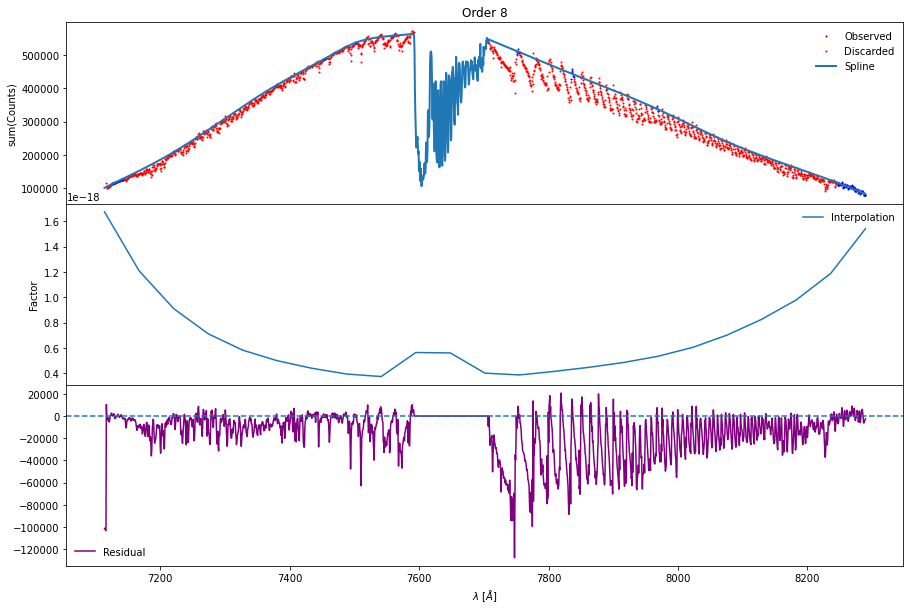

In [19]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(xltt8_1[mask8_1_ltt], yltt8_1[mask8_1_ltt],
            ls='', marker='.', markersize=2, label='Observed', color='blue')
axs[0].plot(xltt8_2[mask8_2_ltt], yltt8_2[mask8_2_ltt],
            ls='', marker='.', markersize=2, color='blue')
axs[0].plot(xltt8_1[np.logical_not(mask8_1_ltt)], yltt8_1[np.logical_not(mask8_1_ltt)],
            ls='', marker='.', markersize=2, label='Discarded', color='red')
axs[0].plot(xltt8_2[np.logical_not(mask8_2_ltt)], yltt8_2[np.logical_not(mask8_2_ltt)],
            ls='', marker='.', markersize=2, color='red')
axs[0].plot(ltt7379.wavelength(8), y_est_custom8_ltt, lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('sum(Counts)')
axs[0].set_title('Order 8')

axs[1].plot(simple_ltt7379.lda, factor8_ltt, label='Interpolation')
axs[1].set_ylabel('Factor')
axs[1].legend(frameon=False)

axs[2].plot(ltt7379.wavelength(8), ltt7379.flux(8) - y_est_custom8_ltt,
            label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]');

## Order 9

In [20]:
yltt9_1 = ltt7379.flux(9)[:1056]
xltt9_1 = ltt7379.wavelength(9)[:1056]

yltt9_int = ltt7379.flux(9)[1056:1218]
xltt9_int = ltt7379.wavelength(9)[1056:1218]

yltt9_2 = ltt7379.flux(9)[1218:]
xltt9_2 = ltt7379.wavelength(9)[1218:]

mask9_1_ltt = (xltt9_1 > 6329) * (xltt9_1 < 6387) \
           + (xltt9_1 > 6442.8) * (xltt9_1 < 6446) \
           + (xltt9_1 > 6595) * (xltt9_1 < 6598) \
           + (xltt9_1 > 6666) * (xltt9_1 < 6669) \
           + (xltt9_1 > 6774) * (xltt9_1 < 6778) \
           + (xltt9_1 > 6844) * (xltt9_1 < 6853)

mask9_2_ltt = (xltt9_2 > 6965) * (xltt9_2 < 6974) \
            + (xltt9_2 > 7041) * (xltt9_2 < 7049) \
            + (xltt9_2 > 7112) * (xltt9_2 < 7119) \
            + (xltt9_2 > 7321) * (xltt9_2 < 7360)

knots9_1_ltt = np.array([6338, 6370, 6420, 6596,
                         6667, 6776, 6848])
knots9_2_ltt = np.array([6970, 7045, 7116, 7350, 7359])

In [21]:
model_custom9_1_ltt = get_natural_cubic_spline_model(x=xltt9_1[mask9_1_ltt], 
                                                 y=yltt9_1[mask9_1_ltt], 
                                                 minval=np.min(xltt9_1), 
                                                 maxval=np.max(xltt9_1), 
                                                 knots=knots9_1_ltt)
y_est_custom9_1_ltt = model_custom9_1_ltt.predict(ltt7379.wavelength(9)[:1056])

interp_y9_ltt = interp1d(xltt9_int, yltt9_int, kind='linear', bounds_error=False, 
                     fill_value=np.nan, assume_sorted=True)
y_est_custom9_int_ltt = interp_y9_ltt(xltt9_int)

model_custom9_2_ltt = get_natural_cubic_spline_model(x=xltt9_2[mask9_2_ltt],
                                                 y=yltt9_2[mask9_2_ltt],
                                                 minval=np.min(xltt9_2),
                                                 maxval=np.max(xltt9_2),
                                                 knots=knots9_2_ltt)
y_est_custom9_2_ltt = model_custom9_2_ltt.predict(xltt9_2)

y_est_custom9_ltt = np.concatenate((y_est_custom9_1_ltt, 
                                   y_est_custom9_int_ltt, 
                                   y_est_custom9_2_ltt))

In [22]:
obs_flux9_ltt = spectres(simple_ltt7379.lda, ltt7379.wavelength(9), 
                     y_est_custom9_ltt, verbose=False)
factor9_ltt = reference_lttflux(simple_ltt7379.lda)/obs_flux9_ltt

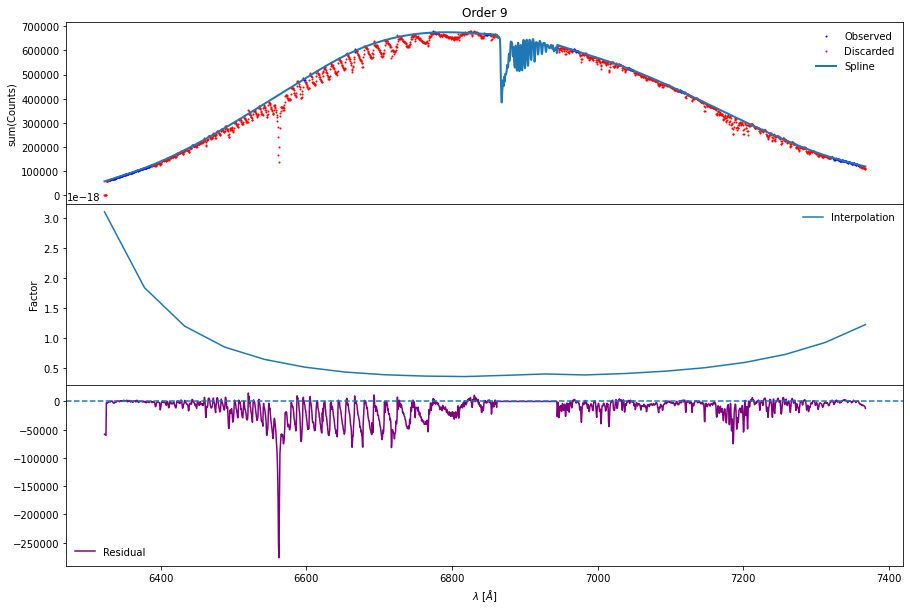

In [23]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(xltt9_1[mask9_1_ltt], yltt9_1[mask9_1_ltt],
            ls='', marker='.', markersize=2, label='Observed', color='blue')
axs[0].plot(xltt9_2[mask9_2_ltt], yltt9_2[mask9_2_ltt],
            ls='', marker='.', markersize=2, color='blue')
axs[0].plot(xltt9_1[np.logical_not(mask9_1_ltt)], yltt9_1[np.logical_not(mask9_1_ltt)],
            ls='', marker='.', markersize=2, label='Discarded', color='red')
axs[0].plot(xltt9_2[np.logical_not(mask9_2_ltt)], yltt9_2[np.logical_not(mask9_2_ltt)],
            ls='', marker='.', markersize=2, color='red')
axs[0].plot(ltt7379.wavelength(9), y_est_custom9_ltt, lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('sum(Counts)')
axs[0].set_title('Order 9')

axs[1].plot(simple_ltt7379.lda, factor9_ltt, label='Interpolation')
axs[1].set_ylabel('Factor')
axs[1].legend(frameon=False)

axs[2].plot(ltt7379.wavelength(9), ltt7379.flux(9) - y_est_custom9_ltt,
            label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]');

## Order 10

In [24]:
yltt10 = ltt7379.flux(10)
xltt10 = ltt7379.wavelength(10)

mask10_ltt = (xltt10 > 5692) * (xltt10 < 5873) \
           + (xltt10 > 5993) * (xltt10 < 5995) \
           + (xltt10 > 6104) * (xltt10 < 6106) \
           + (xltt10 > 6200) * (xltt10 < 6210) \
           + (xltt10 > 6271) * (xltt10 < 6275) \
           + (xltt10 > 6371) * (xltt10 < 6374.5) \
           + (xltt10 > 6616) * (xltt10 < 6625)

knots10_ltt = np.array([5698, 5710, 5758, 5829, 5994,
                        6105, 6205, 6273, 6373, 6600, 6620])

In [25]:
model_custom10_ltt = get_natural_cubic_spline_model(x=xltt10[mask10_ltt],
                                                y=yltt10[mask10_ltt],
                                                minval=np.min(xltt10),
                                                maxval=np.max(xltt10),
                                                knots=knots10_ltt)
y_est_custom10_ltt = model_custom10_ltt.predict(ltt7379.wavelength(10))

In [26]:
obs_flux10_ltt = spectres(simple_ltt7379.lda, ltt7379.wavelength(10), 
                      y_est_custom10_ltt, verbose=False)
factor10_ltt = reference_lttflux(simple_ltt7379.lda)/obs_flux10_ltt

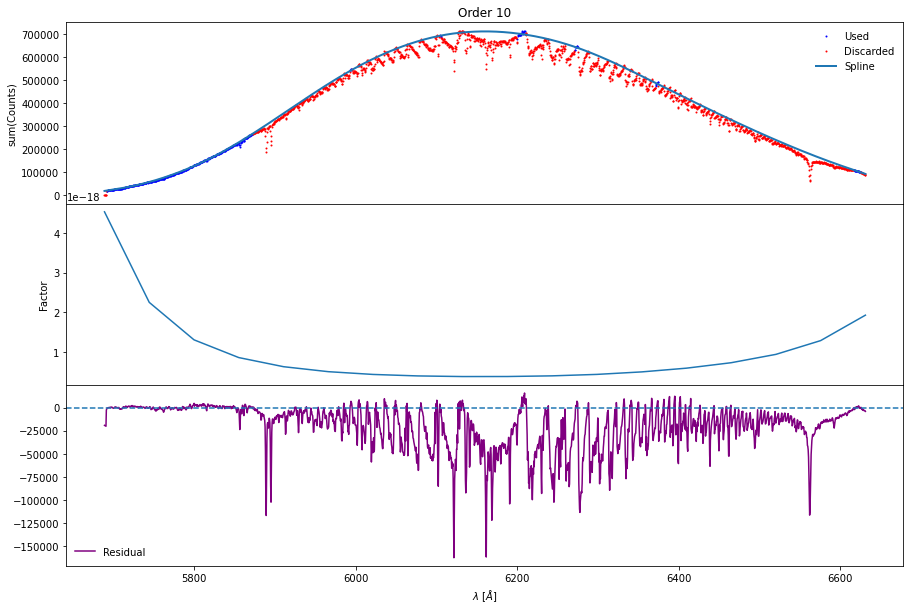

In [27]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(xltt10[mask10_ltt], yltt10[mask10_ltt], ls='', marker='.',
            markersize=2, label='Used', color='blue')
axs[0].plot(xltt10[np.logical_not(mask10_ltt)], yltt10[np.logical_not(mask10_ltt)],
            ls='', marker='.', markersize=2, label='Discarded', color='red')
axs[0].plot(ltt7379.wavelength(10), y_est_custom10_ltt, lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('sum(Counts)')
axs[0].set_title('Order 10')

axs[1].plot(simple_ltt7379.lda, factor10_ltt)
axs[1].set_ylabel('Factor')

axs[2].plot(ltt7379.wavelength(10), ltt7379.flux(10) - y_est_custom10_ltt,
            label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]');

## Order 11

In [28]:
xltt11 = ltt7379.wavelength(11)
yltt11 = ltt7379.flux(11)

mask11_ltt = (xltt11 > 5174) * (xltt11 < 5260) \
            + (xltt11 > 5383.6) * (xltt11 < 5385.1) \
            + (xltt11 > 5457) * (xltt11 < 5461) \
            + (xltt11 > 5536) * (xltt11 < 5541) \
            + (xltt11 > 5644) * (xltt11 < 5648) \
            + (xltt11 > 5742) * (xltt11 < 5745) \
            + (xltt11 > 5819) * (xltt11 < 5850) \
            + (xltt11 > 5904)

knots11_ltt = np.array([5183, 5233, 5384, 5458, 5538,
                        5646, 5743, 5845, 5908, 5940,
                        5978, 6021])

In [29]:
model_custom11_ltt = get_natural_cubic_spline_model(x=xltt11[mask11_ltt],
                                                   y=yltt11[mask11_ltt],
                                                   minval=np.min(xltt11),
                                                   maxval=np.max(xltt11),
                                                   knots=knots11_ltt)
y_est_custom11_ltt = model_custom11_ltt.predict(ltt7379.wavelength(11))

In [30]:
obs_flux11_ltt = spectres(simple_ltt7379.lda, ltt7379.wavelength(11), 
                      y_est_custom11_ltt, verbose=False)
factor11_ltt = reference_lttflux(simple_ltt7379.lda)/obs_flux11_ltt

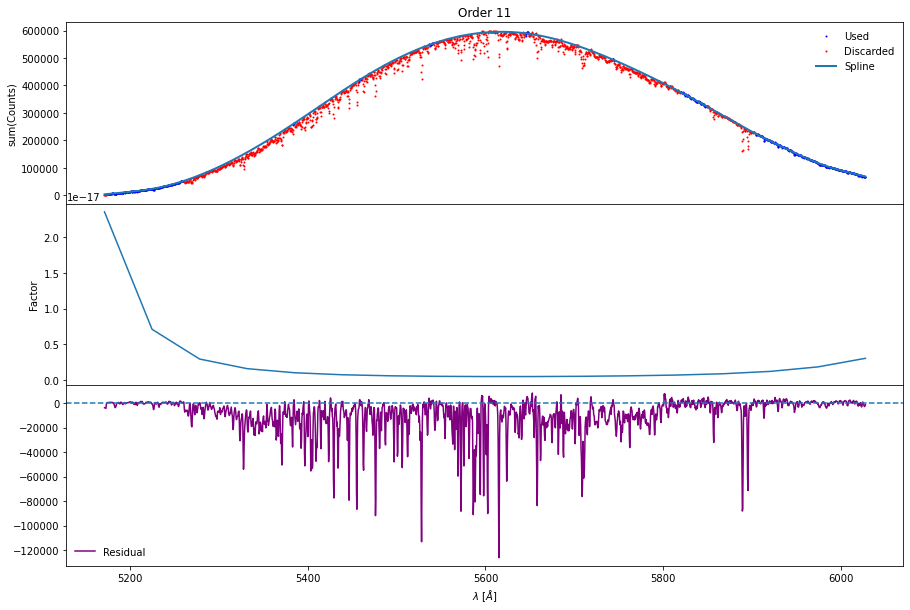

In [31]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(xltt11[mask11_ltt], yltt11[mask11_ltt],
            ls='', marker='.', markersize=2, label='Used', color='blue')
axs[0].plot(xltt11[np.logical_not(mask11_ltt)], yltt11[np.logical_not(mask11_ltt)],
            ls='', marker='.', markersize=2, label='Discarded', color='red')
axs[0].plot(ltt7379.wavelength(11), y_est_custom11_ltt, lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('sum(Counts)')
axs[0].set_title('Order 11')

axs[1].plot(simple_ltt7379.lda, factor11_ltt)
axs[1].set_ylabel('Factor')

axs[2].plot(ltt7379.wavelength(11), ltt7379.flux(11) - y_est_custom11_ltt,
            label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]');

## Order 12

In [32]:
yltt12 = ltt7379.flux(12)
xltt12 = ltt7379.wavelength(12)

mask12_ltt = (xltt12 > 4740) * (xltt12 < 4850) \
           + (xltt12 > 4913) * (xltt12 < 4916) \
           + (xltt12 > 4986) * (xltt12 < 4988) \
           + (xltt12 > 5031) * (xltt12 < 5034) \
           + (xltt12 > 5085) * (xltt12 < 5087) \
           + (xltt12 > 5156) * (xltt12 < 5160) \
           + (xltt12 > 5255) * (xltt12 < 5258) \
           + (xltt12 > 5354) * (xltt12 < 5360) \
           + (xltt12 > 5420)

knots12_ltt = np.array([4750, 4800, 4840, 4914, 4987, 5033,
                        5086, 5158, 5256, 5357, 5440, 5470, 5520])

In [33]:
model_custom12_ltt = get_natural_cubic_spline_model(x=xltt12[mask12_ltt],
                                                y=yltt12[mask12_ltt],
                                                minval=np.min(xltt12),
                                                maxval=np.max(xltt12),
                                                knots=knots12_ltt)
y_est_custom12_ltt = model_custom12_ltt.predict(ltt7379.wavelength(12))

In [34]:
obs_flux12_ltt = spectres(simple_ltt7379.lda, ltt7379.wavelength(12), 
                      y_est_custom12_ltt, verbose=False)
factor12_ltt = reference_lttflux(simple_ltt7379.lda)/obs_flux12_ltt

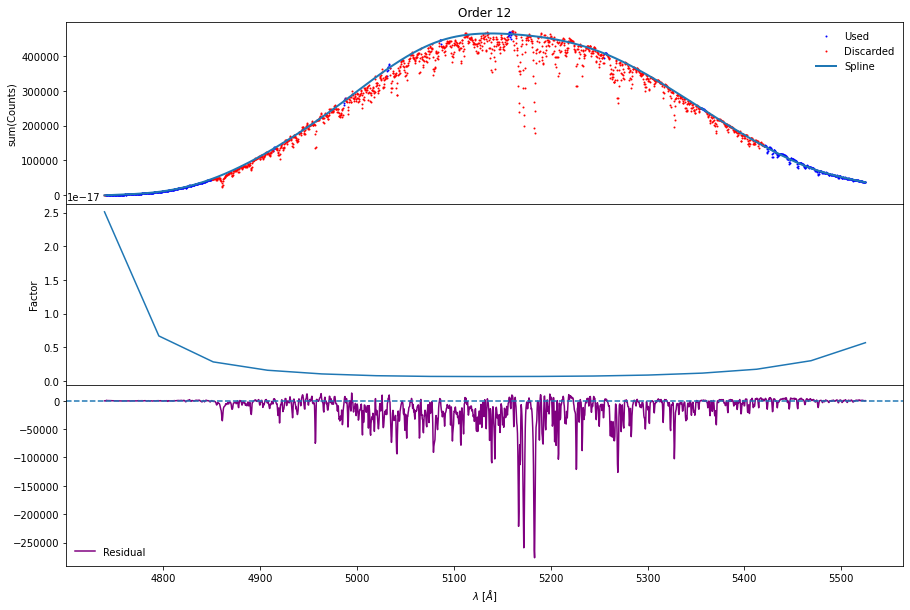

In [35]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(xltt12[mask12_ltt], yltt12[mask12_ltt], ls='',
            marker='.', markersize=2, label='Used', color='blue')
axs[0].plot(xltt12[np.logical_not(mask12_ltt)], yltt12[np.logical_not(mask12_ltt)],
            ls='', marker='.', markersize=2, label='Discarded', color='red')
axs[0].plot(ltt7379.wavelength(12), y_est_custom12_ltt, lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('sum(Counts)')
axs[0].set_title('Order 12')

axs[1].plot(simple_ltt7379.lda, factor12_ltt)
axs[1].set_ylabel('Factor')

axs[2].plot(ltt7379.wavelength(12), ltt7379.flux(12) - y_est_custom12_ltt,
            label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]');

## Order 13

In [36]:
yltt13 = ltt7379.flux(13)
xltt13 = ltt7379.wavelength(13)

mask13_ltt = (xltt13 > 4376) * (xltt13 < 4468) \
           + (xltt13 > 4475) * (xltt13 < 4524) \
           + (xltt13 > 4572) * (xltt13 < 4573) \
           + (xltt13 > 4657) * (xltt13 < 4661) \
           + (xltt13 > 4723) * (xltt13 < 4726) \
           + (xltt13 > 4773) * (xltt13 < 4777) \
           + (xltt13 > 4816) * (xltt13 < 4819) \
           + (xltt13 > 4961)

knots13_ltt = np.array([4379, 4429, 4486, 4520, 4572.5, 4659,
                        4725, 4775, 4818, 4962, 5016, 5051, 5091])

In [37]:
model_custom13_ltt = get_natural_cubic_spline_model(x=xltt13[mask13_ltt],
                                                y=yltt13[mask13_ltt],
                                                minval=np.min(xltt13),
                                                maxval=np.max(xltt13),
                                                knots=knots13_ltt)
y_est_custom13_ltt = model_custom13_ltt.predict(ltt7379.wavelength(13))

In [38]:
obs_flux13_ltt = spectres(simple_ltt7379.lda, ltt7379.wavelength(13),
                      y_est_custom13_ltt, verbose=False)
factor13_ltt = reference_lttflux(simple_ltt7379.lda)/obs_flux13_ltt

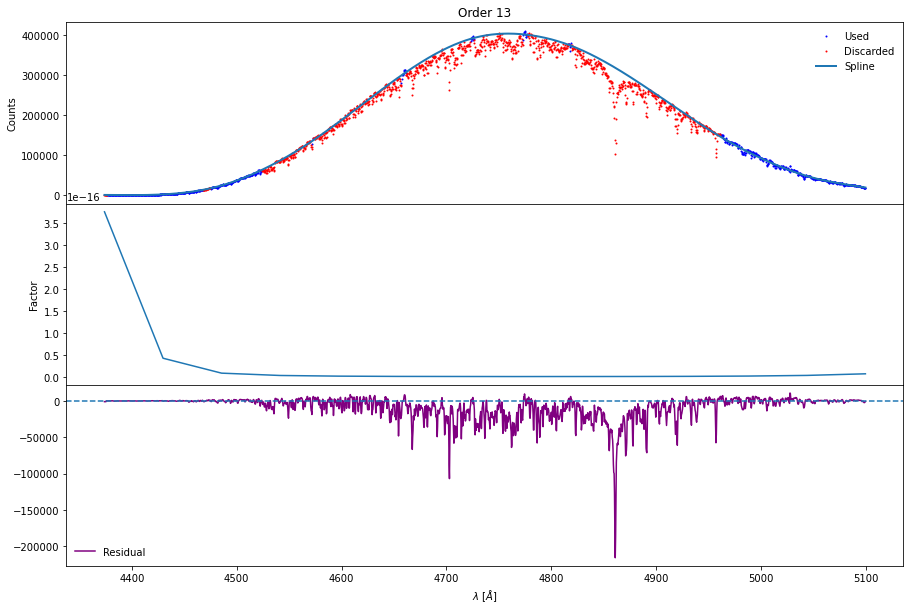

In [39]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(xltt13[mask13_ltt], yltt13[mask13_ltt], ls='',
            marker='.', markersize=2, label='Used', color='blue')
axs[0].plot(xltt13[np.logical_not(mask13_ltt)], yltt13[np.logical_not(mask13_ltt)],
            ls='', marker='.', markersize=2, label='Discarded', color='red')
axs[0].plot(ltt7379.wavelength(13), y_est_custom13_ltt, lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('Counts')
axs[0].set_title('Order 13')

axs[1].plot(simple_ltt7379.lda, factor13_ltt)
axs[1].set_ylabel('Factor')

axs[2].plot(ltt7379.wavelength(13), ltt7379.flux(13) - y_est_custom13_ltt, 
            label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]');

## Order 14

In [40]:
yltt14 = ltt7379.flux(14)
xltt14 = ltt7379.wavelength(14)

mask14_ltt = (xltt14 > 4062) * (xltt14 < 4221) \
           + (xltt14 > 4316) * (xltt14 < 4318) \
           + (xltt14 > 4418) * (xltt14 < 4421) \
           + (xltt14 > 4476) * (xltt14 < 4478) \
           + (xltt14 > 4503) * (xltt14 < 4506) \
           + (xltt14 > 4573) * (xltt14 < 4678) \
           + (xltt14 > 4704)

knots14_ltt = np.array([4068, 4127, 4142, 4317, 4419,
                        4477, 4504, 4614, 4646, 4706, 4729])

In [41]:
model_custom14_ltt = get_natural_cubic_spline_model(x=xltt14[mask14_ltt],
                                                y=yltt14[mask14_ltt],
                                                minval=np.min(xltt14),
                                                maxval=np.max(xltt14),
                                                knots=knots14_ltt)
y_est_custom14_ltt = model_custom14_ltt.predict(ltt7379.wavelength(14))

In [42]:
obs_flux14_ltt = spectres(simple_ltt7379.lda, ltt7379.wavelength(14),
                         y_est_custom14_ltt, verbose=False)
factor14_ltt = reference_lttflux(simple_ltt7379.lda)/obs_flux14_ltt

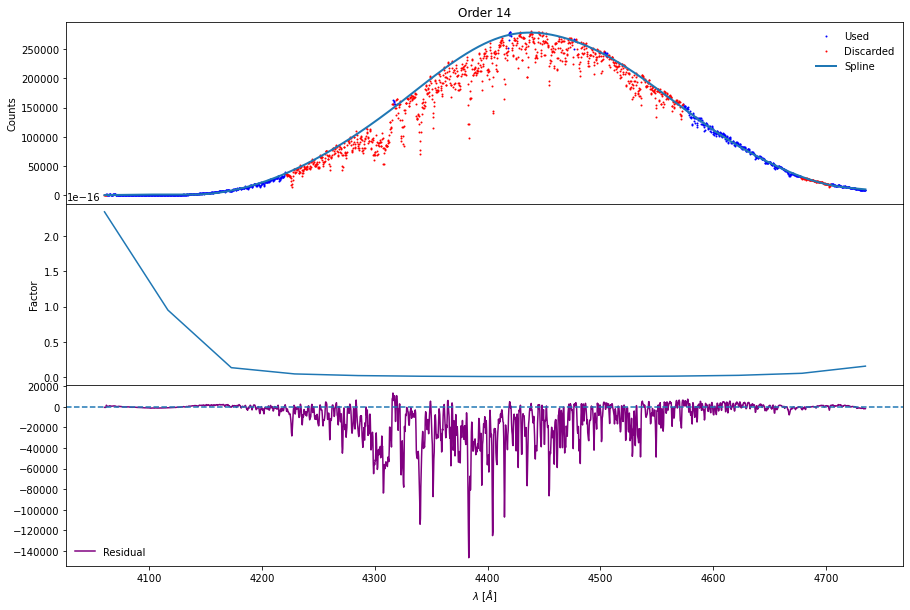

In [43]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(xltt14[mask14_ltt], yltt14[mask14_ltt], ls='', marker='.',
            markersize=2, label='Used', color='blue')
axs[0].plot(xltt14[np.logical_not(mask14_ltt)], yltt14[np.logical_not(mask14_ltt)], ls='',
            marker='.', markersize=2, label='Discarded', color='red')
axs[0].plot(ltt7379.wavelength(14), y_est_custom14_ltt, lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('Counts')
axs[0].set_title('Order 14')

axs[1].plot(simple_ltt7379.lda, factor14_ltt)
axs[1].set_ylabel('Factor')

axs[2].plot(ltt7379.wavelength(14), ltt7379.flux(14) - y_est_custom14_ltt,
            label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]');

## Order 15

In [44]:
yltt15 = ltt7379.flux(15)
xltt15 = ltt7379.wavelength(15)

mask15_ltt = (xltt15 > 3790) * (xltt15 < 3917) \
           + (xltt15 > 3945) * (xltt15 < 3955) \
           + (xltt15 > 4001) * (xltt15 < 4003) \
           + (xltt15 > 4088) * (xltt15 < 4091) \
           + (xltt15 > 4135) * (xltt15 < 4141) \
           + (xltt15 > 4164) * (xltt15 < 4166) \
           + (xltt15 > 4192) * (xltt15 < 4194) \
           + (xltt15 > 4262) * (xltt15 < 4266) \
           + (xltt15 > 4315) * (xltt15 < 4321) \
           + (xltt15 > 4357)

knots15_ltt = np.array([3797, 3840, 3876, 3891, 3950, 4002, 4090,
                        4138, 4165, 4193, 4264, 4320, 4367, 4402])

In [45]:
model_custom15_ltt = get_natural_cubic_spline_model(x=xltt15[mask15_ltt],
                                                y=yltt15[mask15_ltt],
                                                minval=np.min(xltt15),
                                                maxval=np.max(xltt15),
                                                knots=knots15_ltt)
y_est_custom15_ltt = model_custom15_ltt.predict(ltt7379.wavelength(15))

In [46]:
obs_flux15_ltt = spectres(simple_ltt7379.lda, ltt7379.wavelength(15),
                      y_est_custom15_ltt, verbose=False)
factor15_ltt = reference_lttflux(simple_ltt7379.lda)/obs_flux15_ltt

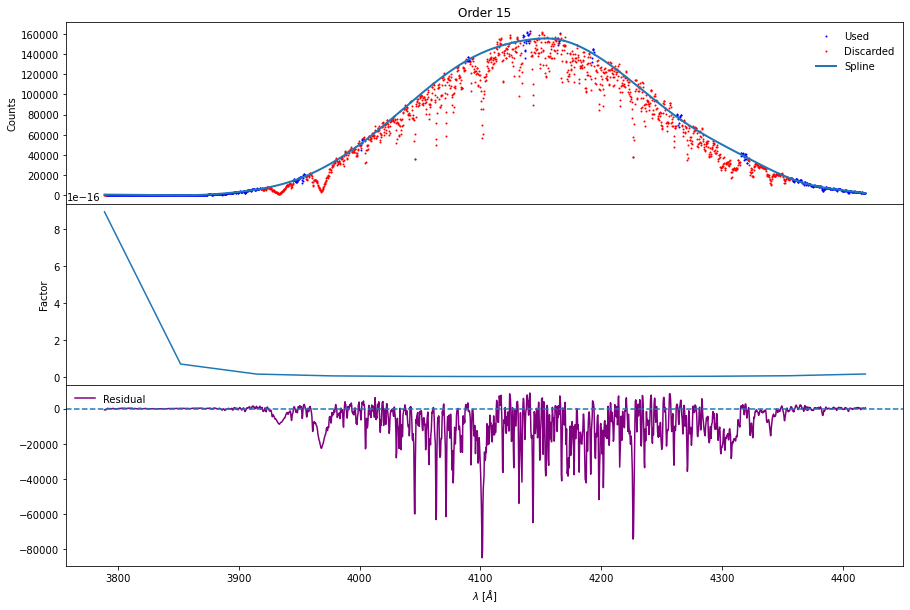

In [47]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(xltt15[mask15_ltt], yltt15[mask15_ltt], ls='', marker='.',
            markersize=2, label='Used', color='blue')
axs[0].plot(xltt15[np.logical_not(mask15_ltt)], yltt15[np.logical_not(mask15_ltt)],
            ls='', marker='.', markersize=2, label='Discarded', color='red')
axs[0].plot(ltt7379.wavelength(15), y_est_custom15_ltt, lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('Counts')
axs[0].set_title('Order 15')

axs[1].plot(simple_ltt7379.lda, factor15_ltt)
axs[1].set_ylabel('Factor')

axs[2].plot(ltt7379.wavelength(15), ltt7379.flux(15) - y_est_custom15_ltt,
            label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]');

## Order 16

In [48]:
yltt16 = ltt7379.flux(16)
xltt16 = ltt7379.wavelength(16)

mask16_ltt = (xltt16 > 3552) * (xltt16 < 3702)  \
           + (xltt16 > 3783) * (xltt16 < 3785) \
           + (xltt16 > 3808) * (xltt16 < 3812) \
           + (xltt16 > 3862) * (xltt16 < 3865) \
           + (xltt16 > 3914) * (xltt16 < 3915.5) \
           + (xltt16 > 4007) * (xltt16 < 4008.5) \
           + (xltt16 > 4059) * (xltt16 < 4062) \
           + (xltt16 > 4110)

knots16_ltt = np.array([3554, 3561, 3618, 3677, 3784, 3811, 3863,
                        3914.5, 4008, 4060, 4120, 4138])

In [49]:
model_custom16_ltt = get_natural_cubic_spline_model(x=xltt16[mask16_ltt],
                                                y=yltt16[mask16_ltt],
                                                minval=np.min(xltt16),
                                                maxval=np.max(xltt16),
                                                knots=knots16_ltt)
y_est_custom16_ltt = model_custom16_ltt.predict(ltt7379.wavelength(16))

In [50]:
obs_flux16_ltt = spectres(simple_ltt7379.lda, ltt7379.wavelength(16),
                      y_est_custom16_ltt, verbose=False)
factor16_ltt = reference_lttflux(simple_ltt7379.lda)/obs_flux16_ltt

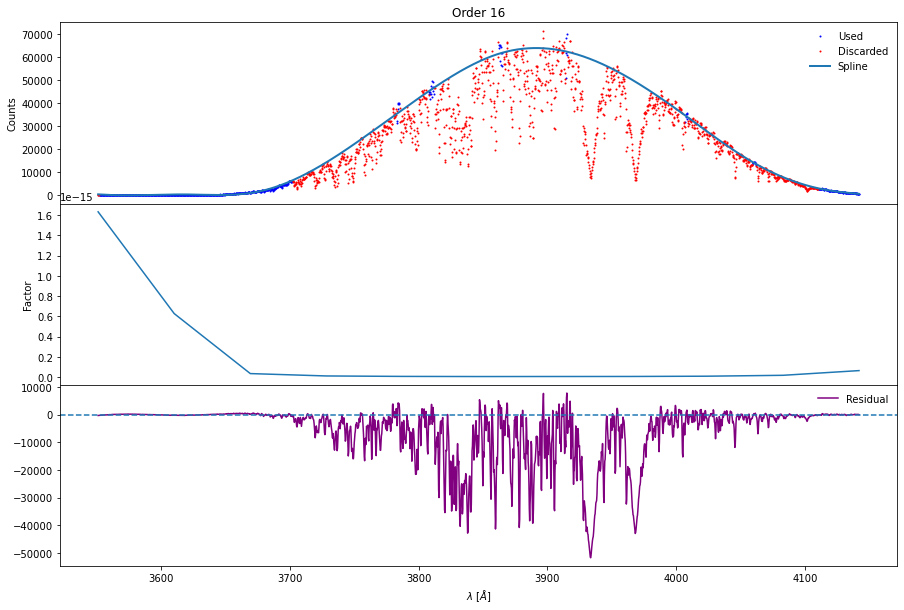

In [51]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(xltt16[mask16_ltt], yltt16[mask16_ltt], ls='', marker='.',
            markersize=2, label='Used', color='blue')
axs[0].plot(xltt16[np.logical_not(mask16_ltt)], yltt16[np.logical_not(mask16_ltt)],
            ls='', marker='.', markersize=2, label='Discarded', color='red')
axs[0].plot(ltt7379.wavelength(16), y_est_custom16_ltt, lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('Counts')
axs[0].set_title('Order 16')

axs[1].plot(simple_ltt7379.lda, factor16_ltt)
axs[1].set_ylabel('Factor')

axs[2].plot(ltt7379.wavelength(16), ltt7379.flux(16) - y_est_custom16_ltt,
            label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]');

## Order 17

In [52]:
xltt17 = ltt7379.wavelength(17)
yltt17 = ltt7379.flux(17)

mask17_ltt = (xltt17 > 3342) * (xltt17 < 3483) \
           + (xltt17 > 3537) * (xltt17 < 3540) \
           + (xltt17 > 3599.7) * (xltt17 < 3601.5) \
           + (xltt17 > 3625) * (xltt17 < 3627) \
           + (xltt17 > 3658) * (xltt17 < 3659) \
           + (xltt17 > 3698) * (xltt17 < 3700) \
           + (xltt17 > 3728.2) * (xltt17 < 3729.5) \
           + (xltt17 > 3783) * (xltt17 < 3785) \
           + (xltt17 > 3817) * (xltt17 < 3818) \
           + (xltt17 > 3846)

knots17_ltt = np.array([3346, 3368, 3392, 3419, 3461, 3539.3, 3600, 3626,
                        3658.5, 3699, 3729, 3784, 3817.5, 3856, 3892])

In [53]:
model_custom17_ltt = get_natural_cubic_spline_model(x=xltt17[mask17_ltt],
                                                   y=yltt17[mask17_ltt],
                                                   minval=np.min(xltt17),
                                                   maxval=np.max(xltt17),
                                                   knots=knots17_ltt)
y_est_custom17_ltt = model_custom17_ltt.predict(ltt7379.wavelength(17))

In [54]:
obs_flux17_ltt = spectres(simple_ltt7379.lda, ltt7379.wavelength(17),
                         y_est_custom17_ltt, verbose=False)
factor17_ltt = reference_lttflux(simple_ltt7379.lda)/obs_flux17_ltt

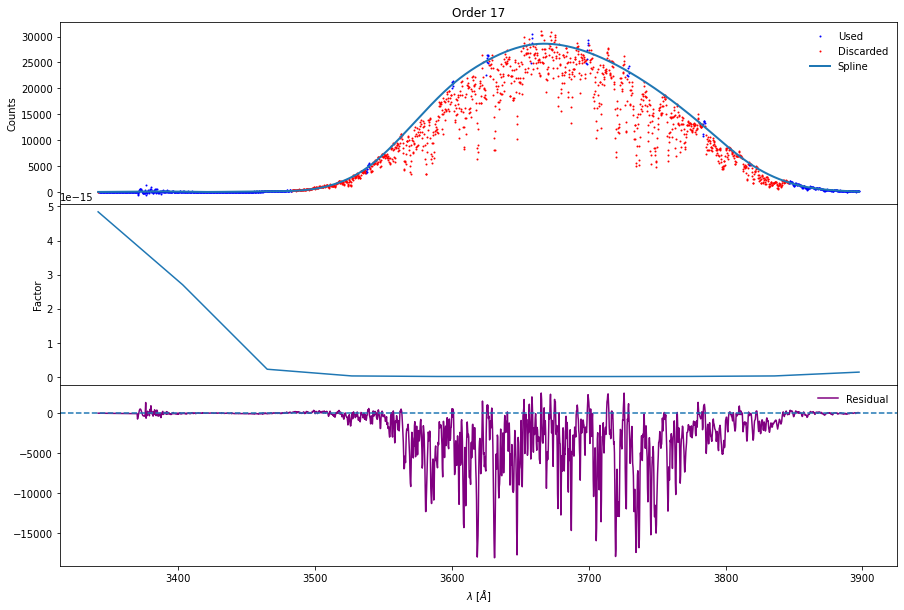

In [55]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(xltt17[mask17_ltt], yltt17[mask17_ltt], ls='', marker='.',
            markersize=2, label='Used', color='blue')
axs[0].plot(xltt17[np.logical_not(mask17_ltt)], yltt17[np.logical_not(mask17_ltt)],
            ls='', marker='.', markersize=2, label='Discarded', color='red')
axs[0].plot(ltt7379.wavelength(17), y_est_custom17_ltt, lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('Counts')
axs[0].set_title('Order 17')

axs[1].plot(simple_ltt7379.lda, factor17_ltt)
axs[1].set_ylabel('Factor')

axs[2].plot(ltt7379.wavelength(17), ltt7379.flux(17) - y_est_custom17_ltt,
            label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]');

## Order 18

In [56]:
xltt18 = ltt7379.wavelength(18)[np.logical_and(ltt7379.wavelength(18) < 3679,
                                         ltt7379.wavelength(18) > 3265)]
yltt18 = ltt7379.flux(18)[np.logical_and(ltt7379.wavelength(18) < 3679,
                                         ltt7379.wavelength(18) > 3265)]

mask18_ltt = (xltt18 > 3286) * (xltt18 < 3355) \
          + (xltt18 < 3396) * (xltt18 > 3398) \
          + (xltt18 > 3419) * (xltt18 < 3421) \
          + (xltt18 > 3434) * (xltt18 < 3436) \
          + (xltt18 > 3469.8) * (xltt18 < 3470.9) \
          + (xltt18 > 3502.9) * (xltt18 < 3503.9) \
          + (xltt18 > 3561.9) * (xltt18 < 3563.7) \
          + (xltt18 > 3590)

knots18_ltt = np.array([3290, 3306, 3325, 3350, 3397,
                       3420, 3435, 3470, 3503, 3563,
                       3616, 3651, 3675])

In [57]:
model_custom18_ltt = get_natural_cubic_spline_model(x=xltt18[mask18_ltt],
                                                   y=yltt18[mask18_ltt],
                                                   minval=np.min(xltt18),
                                                   maxval=np.max(xltt18),
                                                   knots=knots18_ltt)
y_est_custom18_ltt = model_custom18_ltt.predict(ltt7379.wavelength(18))

In [58]:
obs_flux18_ltt = spectres(simple_ltt7379.lda, xltt18,
                         y_est_custom18_ltt, verbose=False)
factor18_ltt = reference_lttflux(simple_ltt7379.lda)/obs_flux18_ltt

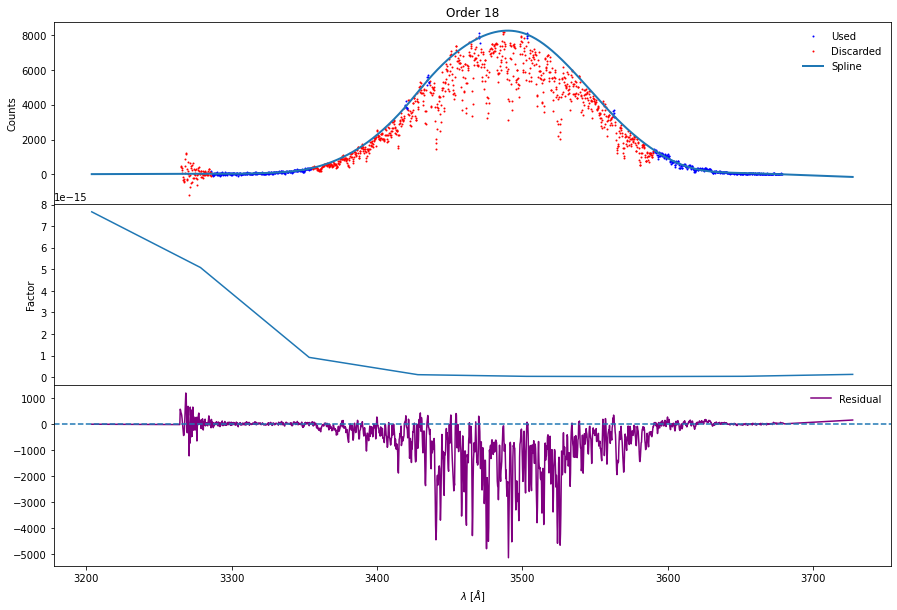

In [59]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(xltt18[mask18_ltt], yltt18[mask18_ltt], ls='', marker='.',
            markersize=2, label='Used', color='blue')
axs[0].plot(xltt18[np.logical_not(mask18_ltt)], yltt18[np.logical_not(mask18_ltt)],
            ls='', marker='.', markersize=2, label='Discarded', color='red')
axs[0].plot(ltt7379.wavelength(18), y_est_custom18_ltt, lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('Counts')
axs[0].set_title('Order 18')

axs[1].plot(simple_ltt7379.lda, factor18_ltt)
axs[1].set_ylabel('Factor')

axs[2].plot(ltt7379.wavelength(18), ltt7379.flux(18) - y_est_custom18_ltt, label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]');

## Order 19

In [60]:
c19ltt = np.logical_and(ltt7379.wavelength(19) > 3186,
                        ltt7379.wavelength(19) < 3452) 
yltt19 = ltt7379.flux(19)[c19ltt]
xltt19 = ltt7379.wavelength(19)[c19ltt]

mask19_ltt = (xltt19 < 3193) \
           + (xltt19 > 3208) * (xltt19 < 3212) \
           + (xltt19 > 3236) * (xltt19 < 3239) \
           + (xltt19 > 3268) * (xltt19 < 3270) \
           + (xltt19 > 3293.3) * (xltt19 < 3295) \
           + (xltt19 > 3324.6) * (xltt19 < 3325.8) \
           + (xltt19 > 3351) * (xltt19 < 3355) \
           + (xltt19 > 3378) * (xltt19 < 3476)

knots19_ltt = np.array([3189, 3210, 3237.5, 3269, 3294, 3325, 3353,
                        3380, 3418, 3446, 3468])

In [61]:
model_custom19_ltt = get_natural_cubic_spline_model(x=xltt19[mask19_ltt],
                                                y=yltt19[mask19_ltt],
                                                minval=np.min(xltt19),
                                                maxval=np.max(xltt19),
                                                knots=knots19_ltt)
y_est_custom19_ltt = model_custom19_ltt.predict(ltt7379.wavelength(19))

In [62]:
obs_flux19_ltt = spectres(simple_ltt7379.lda, xltt19,
                         y_est_custom19_ltt, verbose=False)
factor19_ltt = reference_lttflux(simple_ltt7379.lda)/obs_flux19_ltt

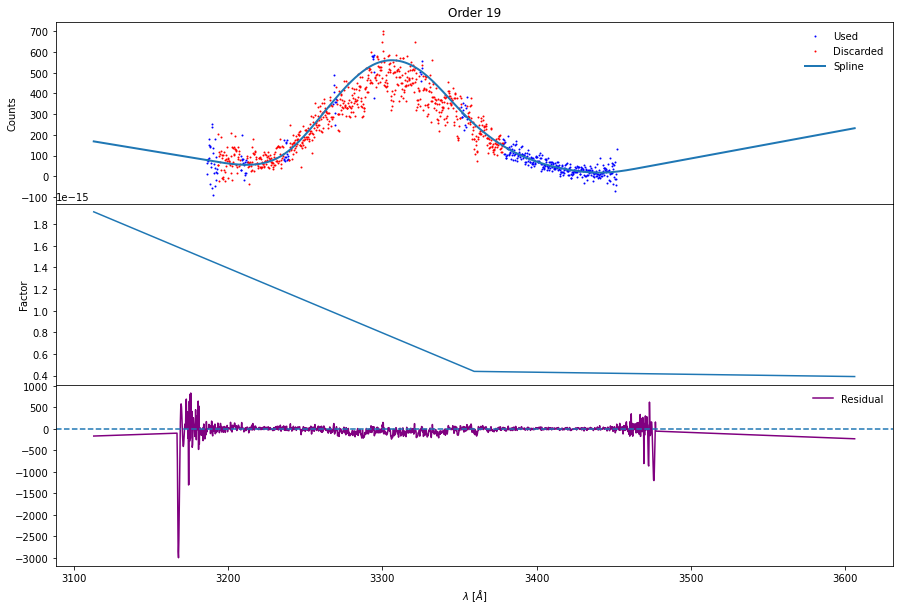

In [63]:
%matplotlib inline
fig, axs = plt.subplots(3, 1, figsize=(15, 10))
fig.subplots_adjust(hspace=0)

axs[0].plot(xltt19[mask19_ltt], yltt19[mask19_ltt],
            ls='', marker='.', markersize=2, label='Used', color='blue')
axs[0].plot(xltt19[np.logical_not(mask19_ltt)],
            yltt19[np.logical_not(mask19_ltt)],
            ls='', marker='.', markersize=2, label='Discarded', color='red')
axs[0].plot(ltt7379.wavelength(19), y_est_custom19_ltt, lw=2, label='Spline')
axs[0].legend(frameon=False)
axs[0].set_ylabel('Counts')
axs[0].set_title('Order 19')

axs[1].plot(simple_ltt7379.lda, factor19_ltt)
axs[1].set_ylabel('Factor')

axs[2].plot(ltt7379.wavelength(19), ltt7379.flux(19) - y_est_custom19_ltt,
            label='Residual', color='purple')
axs[2].legend(frameon=False)
axs[2].axhline(0, ls='--')
axs[2].set_xlabel(r'$\lambda$ [$\AA$]');

# Flux calibration

In [64]:
simple_ltt7379.flux[:] = y_est_custom_model_ltt

In [65]:
spline_flux_ltt = [
    y_est_custom6_ltt,
    y_est_custom7_ltt,
    y_est_custom8_ltt,
    y_est_custom9_ltt,
    y_est_custom10_ltt,
    y_est_custom11_ltt,
    y_est_custom12_ltt,
    y_est_custom13_ltt,
    y_est_custom14_ltt,
    y_est_custom15_ltt,
    y_est_custom16_ltt,
    y_est_custom17_ltt,
    y_est_custom18_ltt,
    y_est_custom19_ltt,
]

In [66]:
for i in range(6, 20):
    ltt7379.flux(i)[:] =  spline_flux_ltt[i - 6]
    print('Order {:} succesful for LTT'.format(i))

Order 6 succesful for LTT
Order 7 succesful for LTT
Order 8 succesful for LTT
Order 9 succesful for LTT
Order 10 succesful for LTT
Order 11 succesful for LTT
Order 12 succesful for LTT
Order 13 succesful for LTT
Order 14 succesful for LTT
Order 15 succesful for LTT
Order 16 succesful for LTT
Order 17 succesful for LTT
Order 18 succesful for LTT
Order 19 succesful for LTT


In [67]:
flux_calibrate_multispec(J0950, ltt7379, simple_ltt7379)
flux_calibrate_multispec(J1146, ltt7379, simple_ltt7379)
flux_calibrate_multispec(J1444, ltt7379, simple_ltt7379)
flux_calibrate_multispec(J1448, ltt7379, simple_ltt7379)
flux_calibrate_multispec(J2101, ltt7379, simple_ltt7379)

Flux calibrating order : 6

Spectres: new_wavs contains values outside the range in spec_wavs, new_fluxes and new_errs will be filled with the value set in the 'fill' keyword argument. 

Flux calibrating order : 7
Flux calibrating order : 8

Spectres: new_wavs contains values outside the range in spec_wavs, new_fluxes and new_errs will be filled with the value set in the 'fill' keyword argument. 

Flux calibrating order : 9

Spectres: new_wavs contains values outside the range in spec_wavs, new_fluxes and new_errs will be filled with the value set in the 'fill' keyword argument. 

Flux calibrating order : 10

Spectres: new_wavs contains values outside the range in spec_wavs, new_fluxes and new_errs will be filled with the value set in the 'fill' keyword argument. 

Flux calibrating order : 11

Spectres: new_wavs contains values outside the range in spec_wavs, new_fluxes and new_errs will be filled with the value set in the 'fill' keyword argument. 

Flux calibrating order : 12

Spectre

/home/benjamin/Documents/analogs/magE/spec/spec_classes.py:182: RuntimeWarning: divide by zero encountered in true_divide
  calibration_factor = reference_flux(ref_lda) / obs_flux
/home/benjamin/Documents/analogs/magE/spec/spec_classes.py:184: RuntimeWarning: invalid value encountered in multiply
  calibrated_flux = multispec_target.flux(order) * calibration_factor
/home/benjamin/Documents/analogs/magE/spec/spec_classes.py:185: RuntimeWarning: invalid value encountered in multiply
  calibrated_error = multispec_target.noise(order) * calibration_factor



Spectres: new_wavs contains values outside the range in spec_wavs, new_fluxes and new_errs will be filled with the value set in the 'fill' keyword argument. 

Flux calibrating order : 13

Spectres: new_wavs contains values outside the range in spec_wavs, new_fluxes and new_errs will be filled with the value set in the 'fill' keyword argument. 

Flux calibrating order : 14

Spectres: new_wavs contains values outside the range in spec_wavs, new_fluxes and new_errs will be filled with the value set in the 'fill' keyword argument. 

Flux calibrating order : 15

Spectres: new_wavs contains values outside the range in spec_wavs, new_fluxes and new_errs will be filled with the value set in the 'fill' keyword argument. 

Flux calibrating order : 16

Spectres: new_wavs contains values outside the range in spec_wavs, new_fluxes and new_errs will be filled with the value set in the 'fill' keyword argument. 

Flux calibrating order : 17

Spectres: new_wavs contains values outside the range in spe

In [68]:
#J0950.to_fits("/home/benjamin/Documents/analogs/specs/fits/j0950+0042.fits")
#J1146.to_fits("/home/benjamin/Documents/analogs/specs/fits/j1146+0053.fits")
#J1444.to_fits("/home/benjamin/Documents/analogs/specs/fits/j1444+0409.fits")
#J1448.to_fits("/home/benjamin/Documents/analogs/specs/fits/j1448-0110.fits")
#J2101.to_fits("/home/benjamin/Documents/analogs/specs/fits/j2101-0555.fits")

In [108]:
dict_orders = {6:[9520,10350],
               7:[8150,9480],
               8:[7120,8290],
               9:[6331,7365],
               10:[5820,6590],
               11:[5212,6000],
               12:[4780,5524],
               13:[4645,5090],
               14:[4260,4712],
               15:[4089,4297],
               16:[3770,4091]}

<ErrorbarContainer object of 3 artists>

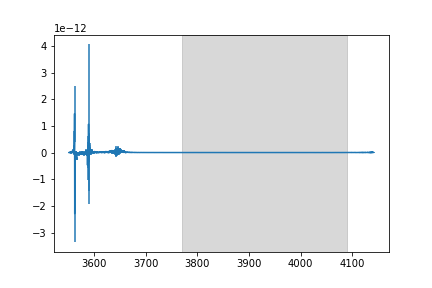

In [109]:
%matplotlib widget
i=16
plt.axvspan(dict_orders[i][0], dict_orders[i][1], color='gray', alpha=0.3)
plt.errorbar(J2101.wavelength(i), J2101.flux(i), J2101.noise(i))